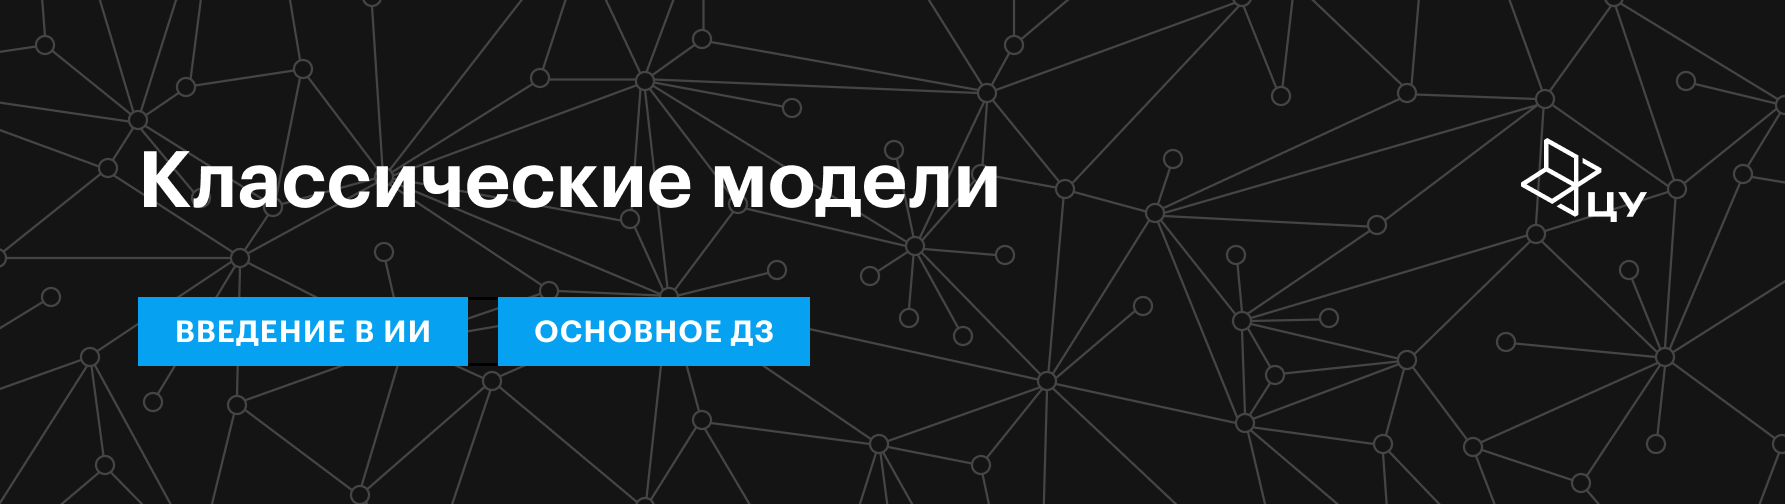

# Домашнее задание по теме «ML-модели»

В этом задании ты потренируешься реализовывать пайплайн обучения  ML-моделей. В задании приветствуются размышления, выдвижение предположений и изложение собственных мыслей.

> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
> 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Визуализации обязательны.
>
> 7. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.
>
> 8. Оформляй все выводы (портрет банка, портрет клиента, бизнес-решение) в markdown-тексте.
>
> 9. Фиксируй random_state для воспроизводимости результатов.


## Легенда

Ты претендуешь на позицию главного аналитика небольшого банка.

Предыдущего аналитика уличили в мошеннической схеме и выгнали с позором. Его работа привела банк к финансовым проблемам, поэтому тебе доверили заняться оптимизацией выдачи кредитов — ещё не успели посвятить в тонкости дел, но работы уже подкинули.

Твоя задача — быстро разобраться в данных, найти закономерности и предложить несколько ML-моделей, которые могут ускорить принятие решений. От того, как хорошо ты справишься, зависит твоё будущее и будущее банка. О подробностях задания — читай ниже. Удачи!



## О датасете

Банк предоставил датасет, который содержит исторические данные по заявкам на кредит и результатам его выдачи.

Целевая переменная: `Loan_Status` — выдаст банк клиенту кредит или нет.
* `Y` — кредит погашен / проблем не было.  
* `N` — кредит проблемный / невозврат.

* `Loan_ID` — идентификатор заявки.
* `Gender` — пол заявителя (`Male` — мужчина, `Female` — женщина).
* `Married` — семейное положение (`Yes` — состоит в браке, `No` — не состоит).
* `Dependents` — количество иждивенцев у заявителя (`0`, `1`, `2`, `3+` — три и более).
* `Education` — уровень образования (`Graduate` — есть высшее/оконченное образование, `Not Graduate` — нет).
* `Self_Employed` — занятость (`Yes` — самозанятый/предприниматель, `No` — работает по найму или не относится к самозанятым).
* `ApplicantIncome` — доход основного заявителя.
* `CoapplicantIncome` — доход созаёмщика (если созаёмщика нет, часто стоит `0`).
* `LoanAmount` — сумма кредита, которую запрашивает клиент (в условных единицах датасета).
* `Loan_Amount_Term` — срок кредита в днях.
* `Credit_History` — показатель кредитной истории (`1` — кредитная история есть и/или считается «хорошей», `0` — кредитной истории нет и/или она «плохая»).
* `Property_Area` — тип местности проживания (`Urban` — город, `Semiurban` — пригород/полугородская зона, `Rural` — сельская местность).



## Задание 1 [4 балла]

Проведи EDA. Эта часть домашнего задания проверит твои аналитические навыки.

1) Найди зависимости между признаками **[1 балл].**
2) Найди корреляции или зависимости с целевой переменной **[1 балл].**
3) Подготовь данные к четвёртому пункту задания — обработай пропуски и предобработай категориальные признаки **[1 балл].**
4) На основе датасета опиши самые значимые и характерные признаки, приведи ключевые статистики и сделай выводы о природе поведения — составь портреты **[1 балл]:**
    - банка,
    - типичного «хорошего» клиента — того, кому выдавали кредит,
    - типичного «плохого» клиента — того, кому не выдавали кредит.

К каждому пункту задания добавь:

- не менее одной иллюстрации или графика;
- не менее одного вывода. В выводах должен быть развёрнутый ответ с твоими мыслями, а не сухие факты.

В задании приветствуется творческий подход — запись промежуточных выводов:
- по графикам;
- посчитанным значениям;
- стратегии заполнения пропусков и так далее.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [72]:
!gdown 1hEQp8v8xUSTnNyZjiY7pGZvmzfczib19

Downloading...
From: https://drive.google.com/uc?id=1hEQp8v8xUSTnNyZjiY7pGZvmzfczib19
To: /content/dataset.csv
100% 38.0k/38.0k [00:00<00:00, 44.8MB/s]


In [73]:
df = pd.read_csv("/content/dataset.csv")
df.head()
df.shape


(614, 13)

Чтобы начать обрабатывать данные и корреляции, нам нужно привести все данные к подходящему виду. Сначала обработаем пропуски, потом приведем к виду, который позволит изучить корреляции

In [74]:
df["Loan_Status"].unique()

array(['Y', 'N'], dtype=object)

In [75]:
df = df.set_index("Loan_ID")
df["Loan_Status"] = df["Loan_Status"] == "Y"

Выберем как индекс Loan_ID. Loan_Status приведем к булевому виду


Приведем Gender к нормальному виду, предварительно решив, что мы будем делать с nan в таблице. Ниже смотрим и видим, что процент выданных кредитов женщинами и мужчинам практически идентичен, поэтому мы можем без проблем заменить nan чем угодно, после чего приведем к булевому виду, где True - Мужчина, а False - Женщина

In [76]:
pd.crosstab(
    df["Gender"],
    df["Loan_Status"],
    normalize="index"
)
df["Gender"] = (df["Gender"] == "Male")

Как мы видим ниже, корреляция с Married на выдачу имеется, но пропусков настолько мало, что это практически не будет влиять на статистику, поэтому мы просто заполним модой

In [77]:
pd.crosstab(
    df["Married"],
    df["Loan_Status"],
    normalize="index"
)
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Married"] = df["Married"] == "Yes"

Аналогично, прямой корреляции с количеством детей нет, но с 2 детьми чаще всего выдают кредиты, не очень понятно, почему. Поскольку мало, опять просто заполним модой

In [78]:
df["Dependents"].isna().sum()

np.int64(15)

In [79]:
pd.crosstab(
    df["Dependents"],
    df["Loan_Status"],
    normalize="index"
)

Loan_Status,False,True
Dependents,,
0,0.310145,0.689855
1,0.352941,0.647059
2,0.247525,0.752475
3+,0.352941,0.647059


In [80]:
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

Ну и ещё заменим теперь на числовые значения, взяв 3+ как 3.

In [81]:
mapping = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3+": 3
}

df["Dependents"] = df["Dependents"].map(mapping)

In [82]:
df.head(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,True,False,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,True
LP001003,True,True,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,False
LP001005,True,True,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,True
LP001006,True,True,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,True
LP001008,True,False,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,True


Отсутсвующих значений у Education нет, поэтому просто переведем в булевый формат

In [83]:
df["Education"] = (df["Education"] == "Graduate")

Корреляции между Self_Employed и Loan_Status снова нет, поэтому просто заменим модой

In [84]:
pd.crosstab(
    df["Self_Employed"],
    df["Loan_Status"],
    normalize="index"
)
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

In [85]:
df["Self_Employed"] = (df["Self_Employed"] == "Yes")

LoanAmount заполним отсутствующие значения медианой

In [86]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

Property_Area закодируем с OneHotEncoder, потому что нет корреляции между этими признаками

In [87]:
pd.crosstab(
    df["Property_Area"],
    df["Loan_Status"],
    normalize="index"
)


Loan_Status,False,True
Property_Area,,
Rural,0.385475,0.614525
Semiurban,0.231760,0.768240
Urban,0.341584,0.658416


In [88]:
df = pd.get_dummies(df, columns=["Property_Area"], drop_first=True)

In [89]:
np.any(df.isna(), axis=0)

,0
Gender,False
Married,False
Dependents,False
Education,False
Self_Employed,False
ApplicantIncome,False
CoapplicantIncome,False
LoanAmount,False
Loan_Amount_Term,True
Credit_History,True


В Credit_History огромная корреляция с выдачей кредита, это, видимо, ключевой признак. А также целых 50 пропусков, это почти 10% данных. Поскольку это определяющий признак, отсутствие подтвержденных данных мы будем считать как отсутствие истории

In [90]:
df["Credit_History"].isna().sum()

np.int64(50)

In [91]:

pd.crosstab(
    df["Credit_History"],
    df["Loan_Status"],
    normalize="index"
)
df["Credit_History"] = df["Credit_History"].fillna(0)

In [92]:
df.head(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,True,False,0,True,False,5849,0.0,128.0,360.0,1.0,True,False,True
LP001003,True,True,1,True,False,4583,1508.0,128.0,360.0,1.0,False,False,False
LP001005,True,True,0,True,True,3000,0.0,66.0,360.0,1.0,True,False,True
LP001006,True,True,0,False,False,2583,2358.0,120.0,360.0,1.0,True,False,True
LP001008,True,False,0,True,False,6000,0.0,141.0,360.0,1.0,True,False,True


Понятия не имею, как кредитная организация умудрилась потерять данные колва дней кредита, думаю, ей стоит уволить кого-то. Заполним медианой, тем более она ярко выражена

14


<Axes: >

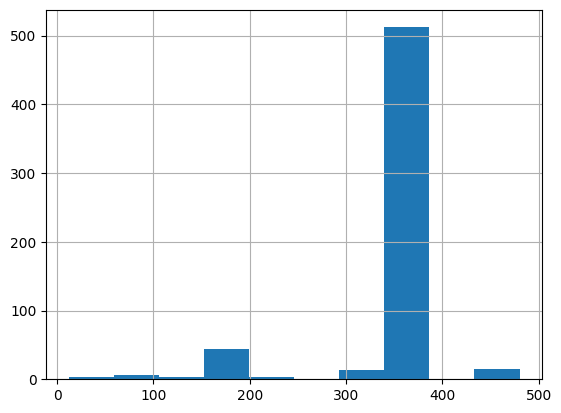

In [93]:
print(df['Loan_Amount_Term'].isna().sum() )
df["Loan_Amount_Term"].hist()

In [94]:
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

In [95]:
np.sum(df.isna(),axis=0)

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


Мы очистили массив данных от пропусков, теперь наконец можем посмотреть на полную картину корреляций

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, LP001002 to LP002990
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    bool   
 1   Married                  614 non-null    bool   
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    bool   
 4   Self_Employed            614 non-null    bool   
 5   ApplicantIncome          614 non-null    int64  
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    float64
 10  Loan_Status              614 non-null    bool   
 11  Property_Area_Semiurban  614 non-null    bool   
 12  Property_Area_Urban      614 non-null    bool   
dtypes: bool(7), float64(4), int64(2)
memory usage: 53.9+ KB


Посмотрим на матрицу корреляции, отбросив малозначимые признаки

<Axes: >

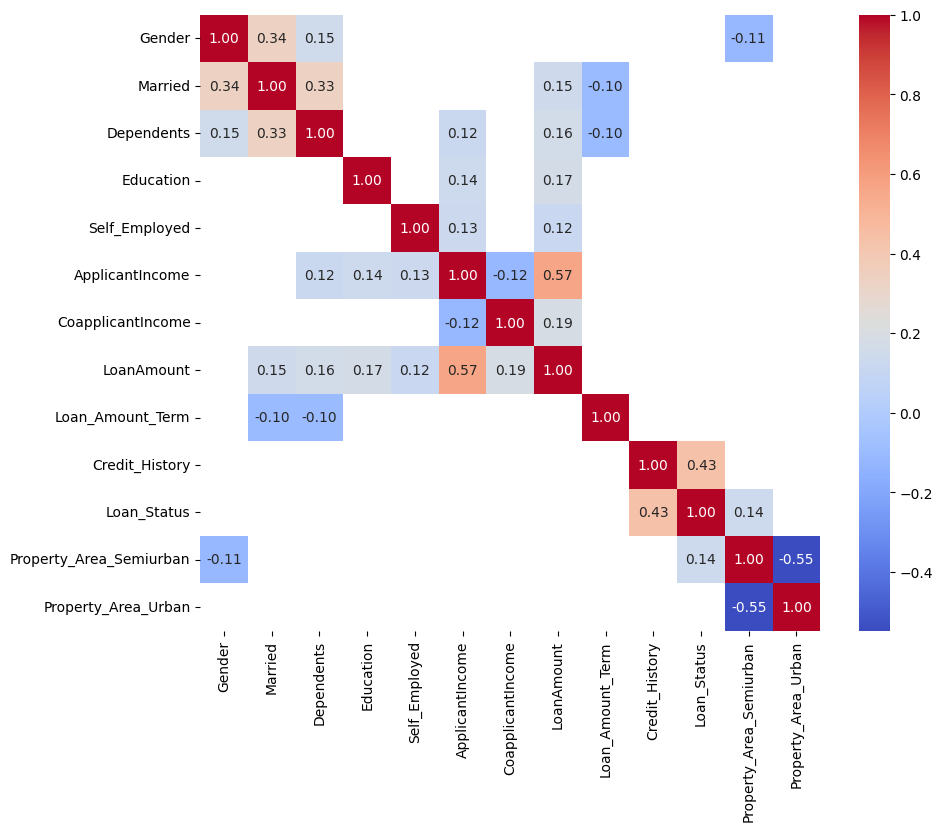

In [97]:
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", mask=np.abs(corr)<0.1)

Сначала рассмотрим просто коррелирующие признаки: Именно в этом датасете мужчины чаще являются женатыми, что может показывать недостаточную репрезентацивность выборки, либо довольно успешную репрезентацию лгбт*. Женатые, очевидно, коррелируют с количеством детей.

* движение признано экстремистским и запрещено в России

Как мы видим, довольно много признаков коррелируют с колвом долга. В основном коррелирует именно доход, что очевидно, так как показывает платежеспособность клиента. Также коррелирует с этим образование и колво детей, но они также коррелируют с доходом, что просто показывает статус человека. Также, из интересного, имеется корреляция с местом проживания человека. Возможно, богатые люди больше предпочитают жить в пригороде, что и создает корреляцию


Значительно коррелирует история кредита с выдачей кредита, что как раз показывает важность клиента и его платежеспособность: Если он раньше вернул кредит, то и сейчас вернет с большей вероятностью

Банк выглядит довольно консервативным, поскольку опирается на клиентов, которые уже брали кредит и с большим желанием дает больший кредит тем, кто уже располагает большим доходом. Например, банк с меньшей вероятностью даст кредит для развития бизнеса.

Хорошим клиентом является образованный клиент мужчина, живущий в пригороде, с высоким доходом, несколькими детьми и женатым.
Плохим, наоборот, является необразованный клиент, живущий где угодно, с низким дохом, без детей и с супруга.

In [98]:
df['Loan_Status'].mean()

np.float64(0.6872964169381107)

запомним, что кредит в среднем выдается 69% подающих

## Задание 2 [6 баллов]

<!--На данный момент у банка небольшие финансовые трудности, поэтому руководство думает над следующими стратегиями выхода из кризиса:

### Новые горизонты

Можно рискнуть и начать активно выдавать кредиты желающим его взять.

* **Цель:** найти как можно больше людей, способных закрыть свой долг с процентами

* **Ограничение:** не менее трети людей из тех, кому мы одобрили кредит, должны на самом деле смочь его выплатить (финансисты рассчитали, что это - точка безубыточности)

### Жесткая экономия

Можно наоборот, свернуть активное кредитование и выдавать кредит только "надежным" людям

* **Цель:** минимизировать долю людей, которым мы выдали кредит, но которые не смогли его выплатить

* **Ограничение:** не менее 80% людей из тех, кому мы одобрили кредит, должны на самом деле смочь его выплатить

**От вас требуется:**
1) Построить ML модели, удовлетворяющие данным требованиям
2) Оформить блок кода, позволяющий ввести вручную данные о заемщике и получить ответ, одобрила бы модель ему кредит или нет (руководство хочет лично оценить модели).


**Формальные требования:**

1) Построить не менее 2-х моделей на стратегию "Новые горизонты" **[2.5 балла]**

2) Построить не менее 2-х моделей на стратегию "Жёсткая экономия" **[2.5 балла]**

3) Сравнить построенные модели между собой. Выбрать лучшую и пояснить, почему была выбрана именно она (Precision, Recall, Accuracy, интерпретируемость и т.п) Очень важно писать развернутые выводы и свои мысли! **[1 балл]**
 -->

Построй модели и проведи анализ.

1) Построй не менее двух моделей для стратегии «Новые горизонты» **[2 балла]**.

2) Построй не менее двух моделей для стратегии «Жёсткая экономия» **[2 балла]**.

3) Сравни построенные модели между собой. Выбери лучшую и поясни своё решение с опорой на показатели. Например, Precision, Recall, Accuracy, интерпретируемость и тому подобное. Обязательно фиксируй свои мысли и развёрнутые выводы **[1 балл]**.

4) Оформи блок кода, позволяющий ввести данные заявителя вручную и получить ответ: одобрила бы модель кредит или нет (руководство хочет оценить модели лично) **[1 балл]**.

#### Описание задания

У банка финансовые трудности, поэтому руководство думает над двумя стратегиями выхода из кризиса.

| Стратегия  | Описание | Цель | Ограничение |            
|----------------|----------------------------|---------------------------------|-------------------------------|
| «Новые горизонты» | Рискнуть, и начать активно выдавать кредиты всем, <br>кто хочет их получить | Найти как можно больше людей,<br> способных закрыть свой долг с процентами | Не менее трети из тех, кто получил одобрение кредита, <br>должны в итоге его выплатить. Финансисты рассчитали, <br>что это точка безубыточности|
| «Жёсткая экономия» | Свернуть активное кредитование<br> и выдавать кредит только «надёжным» людям    | Минимизировать долю тех людей,<br> кто получил кредит, но не смог его выплатить | Не менее 80% людей из тех, кому банк одобрил <br>кредит, должны реально его выплатить |


Начнем с разделения данных, после чего нормализуем их

In [99]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Loan_Status")
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Воспользуемся логистической регрессией и рандомным лесом

In [101]:
from sklearn.linear_model import LogisticRegression

logic_model = LogisticRegression(max_iter=1000)
logic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [102]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=42)
forest_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [103]:
logic_model.predict_proba(X_test_scaled)

array([[0.79170172, 0.20829828],
       [0.09759563, 0.90240437],
       [0.24393182, 0.75606818],
       [0.20780276, 0.79219724],
       [0.10988638, 0.89011362],
       [0.20395792, 0.79604208],
       [0.12118946, 0.87881054],
       [0.13394247, 0.86605753],
       [0.27627384, 0.72372616],
       [0.25566108, 0.74433892],
       [0.1238698 , 0.8761302 ],
       [0.16484236, 0.83515764],
       [0.11156213, 0.88843787],
       [0.19608177, 0.80391823],
       [0.64600312, 0.35399688],
       [0.60690315, 0.39309685],
       [0.29106816, 0.70893184],
       [0.60328108, 0.39671892],
       [0.549623  , 0.450377  ],
       [0.20691359, 0.79308641],
       [0.59915922, 0.40084078],
       [0.44169396, 0.55830604],
       [0.58956574, 0.41043426],
       [0.11891882, 0.88108118],
       [0.12209392, 0.87790608],
       [0.16531436, 0.83468564],
       [0.23609708, 0.76390292],
       [0.25192723, 0.74807277],
       [0.64826171, 0.35173829],
       [0.20670164, 0.79329836],
       [0.

In [104]:
logic_prob = logic_model.predict_proba(X_test_scaled)[:, 1]
forest_prob = forest_model.predict_proba(X_test_scaled)[:, 1]

Сначала рассмотрим новые горизонты. Как мы заметили ранее, в изначально выданной выборке 69% кредитов было выплачено, поэтому при желании получить 33% выплат довольно очевидно, что модель предложит выдавать кредиты всем. Давайте это проверим, перебирая threshold с желанием сохранить precision над 0.33.

Precision это доля клиентов, которым модель одобрила кредит, и которые действительно его выплатили.
Recall это доля клиентов, которые могли выплатить кредит, и которым модель действительно одобрила кредит.
Если модель достигла желаемого Precision, мы будем максимизировать Recall, чтобы максимизировать прибыль


In [105]:
from sklearn.metrics import precision_score, recall_score

best_t = 0
best_recall = 0.0

for t in np.arange(0, 0.6, 0.01):
    preds = (logic_prob >= t)
    if precision_score(y_test, preds) >= 0.33 and recall_score(y_test, preds) > best_recall:
      best_t = t
      best_recall = recall_score(y_test, preds)
print(best_t, best_recall)

0.0 1.0


In [106]:
from sklearn.metrics import precision_score, recall_score


best_t = 0
best_recall = 0.0

for t in np.arange(0, 0.6, 0.01):
    preds = (forest_prob >= t)
    if precision_score(y_test, preds) >= 0.33 and recall_score(y_test, preds) > best_recall:
      best_t = t
      best_recall = recall_score(y_test, preds)
print(best_t, best_recall)

0.0 1.0


Действительно, в обоих моделях лучшим вариантом было выдать кредит вообще всем, так как это поддерживает требуемый precision, а также максимизирует recall.

Теперь рассмотрим Жесткую экономию. Требуемый presicion = 0.8, при нем будем также максимизировать recall


In [107]:
from sklearn.metrics import precision_score, recall_score


best_t_logic = 0
best_recall = 0.0

for t in np.arange(0, 1, 0.01):
    preds = (logic_prob >= t)
    if precision_score(y_test, preds) >= 0.8 and recall_score(y_test, preds) > best_recall:
      best_t_logic = t
      best_recall = recall_score(y_test, preds)
print(best_t_logic, best_recall)

0.47000000000000003 0.9176470588235294


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

In [108]:
from sklearn.metrics import precision_score, recall_score


best_t_forest = 0
best_recall = 0.0

for t in np.arange(0, 1, 0.01):
    preds = (forest_prob >= t)
    if precision_score(y_test, preds) >= 0.8 and recall_score(y_test, preds) > best_recall:
      best_t_forest = t
      best_recall = recall_score(y_test, preds)
print(best_t_forest, best_recall)

0.45 0.9058823529411765


In [110]:
from sklearn.metrics import classification_report

In [111]:
preds = (logic_prob >= best_t_logic)
print(classification_report(y_test, preds))

preds = (forest_prob >= best_t_forest)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       False       0.73      0.50      0.59        38
        True       0.80      0.92      0.86        85

    accuracy                           0.79       123
   macro avg       0.77      0.71      0.73       123
weighted avg       0.78      0.79      0.78       123

              precision    recall  f1-score   support

       False       0.71      0.53      0.61        38
        True       0.81      0.91      0.86        85

    accuracy                           0.79       123
   macro avg       0.76      0.72      0.73       123
weighted avg       0.78      0.79      0.78       123



Логистическая модель выдала немного больший threshold, предоставив чуть больший recall. В целом, разница небольшая, но мы предпочтем за счет чуть большего recall именно логистическую регрессию как основную модель.

Посмотрим на коэффициенты модели, чтобы выяснить, что она посчитала важными признаками. Мы это можем сделать, так как до этого нормализовали данные.

In [112]:

coef_df = pd.DataFrame({
    "1": X.columns,
    "2": logic_model.coef_[0]
})

coef_df = coef_df.sort_values(by="2", ascending=False)
coef_df

,1,2
9,Credit_History,0.856266
10,Property_Area_Semiurban,0.337180
1,Married,0.275337
3,Education,0.152236
11,Property_Area_Urban,0.091916
7,LoanAmount,0.081577
2,Dependents,0.026660
8,Loan_Amount_Term,0.001021
4,Self_Employed,-0.055730
0,Gender,-0.089174


Как видно и было предположено ранее, кредитная история и жизнь в пригороде влияет больше всего на вероятность возврата кредита. Из интересного, доход абсолютно, даже почти отрицательно коррелирует с вероятностью возврата кредита.

Ниже реализация ручной проверки заявителя.


In [113]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,True,False,0,True,False,5849,0.0,128.0,360.0,1.0,True,False,True
LP001003,True,True,1,True,False,4583,1508.0,128.0,360.0,1.0,False,False,False
LP001005,True,True,0,True,True,3000,0.0,66.0,360.0,1.0,True,False,True
LP001006,True,True,0,False,False,2583,2358.0,120.0,360.0,1.0,True,False,True
LP001008,True,False,0,True,False,6000,0.0,141.0,360.0,1.0,True,False,True


In [114]:
def predict_client():
    print("Введите данные клиента:\n")

    gender = int(input("Gender (1 - Male, 0 - Female): "))
    married = int(input("Married (1 - Yes, 0 - No): "))
    dependents = int(input("Dependents (0,1,2,3): "))
    education = int(input("Education (1 - Graduate, 0 - Not Graduate): "))
    self_employed = int(input("Self_Employed (1 - Yes, 0 - No): "))
    applicant_income = float(input("ApplicantIncome: "))
    coapplicant_income = float(input("CoapplicantIncome: "))
    loan_amount = float(input("LoanAmount: "))
    loan_term = float(input("Loan_Amount_Term: "))
    credit_history = int(input("Credit_History (1 - good, 0 - bad): "))
    property_semiurban = int(input("Property_Area_Semiurban (1/0): "))
    property_urban = int(input("Property_Area_Urban (1/0): "))

    input_data = pd.DataFrame([[
        gender,
        married,
        dependents,
        education,
        self_employed,
        applicant_income,
        coapplicant_income,
        loan_amount,
        loan_term,
        credit_history,
        property_semiurban,
        property_urban
    ]], columns=X.columns)

    proba = logic_model.predict_proba(input_scaled)[0][1]

    threshold = best_t_logic

    print(f"\nВероятность выплаты: {proba:.3f}")

    if proba >= threshold:
        print("Решение модели: КРЕДИТ ОДОБРЕН")
    else:
        print("Решение модели: КРЕДИТ ОТКЛОНЕН")

In [115]:
predict_client()

Введите данные клиента:

Gender (1 - Male, 0 - Female): 0
Married (1 - Yes, 0 - No): 


ValueError: invalid literal for int() with base 10: ''